# Reproduce-first baseline, Tomato ripeness detection & counting

**MSc dissertation · reproduce-first step (before any modification).**

**What this notebook does.** Establishes a working, credible baseline for
tomato-ripeness *detection* and ripe-fruit *counting* on a public dataset,
and anchors the numbers to the dataset's **published baseline**.

**Dataset — Laboro Tomato** (Laboro.AI Inc.)
- 804 images, 10 610 objects, 6 classes = size (big/little) × 3 USDA-style
  ripeness stages (green / half_ripened / fully_ripened).
- Instance segmentation (we use boxes for detection). Licence CC BY-NC-SA 4.0.
- Source: https://github.com/laboroai/LaboroTomato
- Published baseline (official README): **Mask R-CNN R-50-FPN, Box AP = 64.3**
  on `tomato_mixed` (MMDetection, 48 epochs, 4×V100).



## 0. Environment

In [1]:
import sys, platform, torch, ultralytics
print("python     ", sys.version.split()[0])
print("platform   ", platform.platform())
print("torch      ", torch.__version__, "| MPS:", torch.backends.mps.is_available())
print("ultralytics", ultralytics.__version__)
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("device     ", DEVICE)

python      3.13.3
platform    macOS-26.5-arm64-arm-64bit-Mach-O
torch       2.13.0 | MPS: True
ultralytics 8.4.94
device      mps


## 1. Data, Laboro Tomato -> YOLO

The raw dataset ships as COCO instance-segmentation JSON. `prepare_data.py`
converts it to YOLO detection labels (6 classes) and writes `data.yaml`,
keeping the dataset's **native train/test split** (643 / 161 images).

**Data-integrity fix (EXIF orientation).** ~40% of the images (235/643 train,
70/161 val) come from a camera that stores an **EXIF orientation = 6** tag: the
pixels on disk are landscape while the COCO annotations use the upright
(portrait) frame. PIL/OpenCV — and the YOLO training loader — read raw pixels
and ignore EXIF, so on those images the boxes did **not** match the fruit.
`prepare_data.py` bakes the rotation into the pixels (`ImageOps.exif_transpose`)
and strips the tag, so labels and pixels share one frame. The sample below
confirms boxes now sit tightly on the tomatoes.

In [2]:
from pathlib import Path
import yaml
DATA = Path("data/laboro_yolo")
cfg = yaml.safe_load((DATA / "data.yaml").read_text())
print("classes:", cfg["names"])
for split in ("train", "val"):
    n_img = len(list((DATA / "images" / split).glob("*.jpg")))
    n_obj = sum(len(p.read_text().split()) // 5
                for p in (DATA / "labels" / split).glob("*.txt"))
    print(f"{split:>5}: {n_img} images, {n_obj} objects")

classes: ['b_fully_ripened', 'b_half_ripened', 'b_green', 'l_fully_ripened', 'l_half_ripened', 'l_green']
train: 643 images, 7781 objects
  val: 161 images, 1996 objects


### Sample images with ground-truth boxes

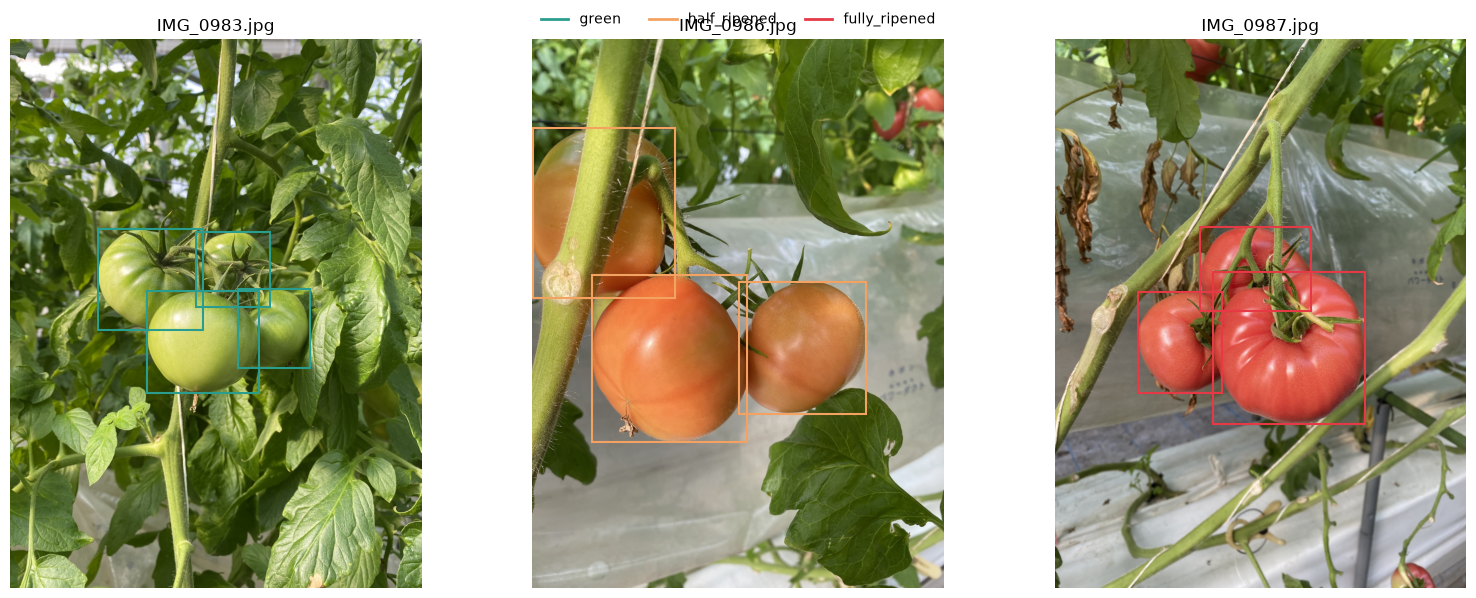

In [3]:
import matplotlib.pyplot as plt, matplotlib.patches as patches
from matplotlib.lines import Line2D
from PIL import Image
# colour by ripeness stage (size collapsed): green / half / fully
STAGE_COLOR = {0:"#e63946",1:"#f4a261",2:"#2a9d8f",3:"#e63946",4:"#f4a261",5:"#2a9d8f"}
LEGEND = [Line2D([0],[0], color=c, lw=2, label=l) for c,l in
          [("#2a9d8f","green"),("#f4a261","half_ripened"),("#e63946","fully_ripened")]]
imgs = sorted((DATA / "images" / "val").glob("*.jpg"))[:3]
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, ip in zip(axes, imgs):
    im = Image.open(ip); W, H = im.size; ax.imshow(im); ax.axis("off"); ax.set_title(ip.name)
    for line in (DATA / "labels" / "val" / (ip.stem + ".txt")).read_text().splitlines():
        cls, cx, cy, w, h = line.split(); cls = int(cls)
        cx, cy, w, h = float(cx)*W, float(cy)*H, float(w)*W, float(h)*H
        ax.add_patch(patches.Rectangle((cx-w/2, cy-h/2), w, h, fill=False,
                     edgecolor=STAGE_COLOR[cls], linewidth=1.5))
fig.legend(handles=LEGEND, loc="upper center", ncol=3, frameon=False)
plt.tight_layout(); plt.show()

## 2. Model & training, YOLO11n

YOLO11n (nano, 2.59 M params), COCO-pretrained init. Single protocol:
60 epochs, imgsz 640, batch 16, AdamW (auto), **seed 0**, MPS.

Training takes ~47 min on an Apple M-series and was run once via `train.py`;
the cell below is the exact call (left non-executing so the notebook renders
fast — uncomment to retrain). Evaluation loads the saved `best.pt`.

In [ ]:
# Reproduce training (≈47 min on MPS).
# from ultralytics import YOLO
# YOLO("yolo11n.pt").train(data="data/laboro_yolo/data.yaml",
#     epochs=60, imgsz=640, batch=16, device=DEVICE, seed=0,
#     project="runs", name="laboro_yolo11n_exiffix")
WEIGHTS = "runs/laboro_yolo11n_exiffix/weights/best.pt"
print("using weights:", WEIGHTS)

using weights: runs/laboro_yolo11n_exiffix/weights/best.pt


## 3. Detection metrics vs published baseline

In [5]:
from ultralytics import YOLO
model = YOLO(WEIGHTS)
m = model.val(data="data/laboro_yolo/data.yaml", device=DEVICE, verbose=False).box
ours = {"Box AP (mAP50-95)": m.map, "mAP50": m.map50, "mAP75": m.map75,
        "mean P": m.mp, "mean R": m.mr}
for k, v in ours.items():
    print(f"{k:>18}: {v:.3f}")

Ultralytics 8.4.94 🚀 Python-3.13.3 torch-2.13.0 MPS (Apple M4 Pro)


YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 13125.5±3306.3 MB/s, size: 2963.5 KB)



val: Scanning /Users/chel/Projects/master_diploma/reproduce/data/laboro_yolo/labels/val.cache... 161 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 161/161 27.0Mit/s 0.0s


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 9% ━─────────── 1/11 2.4s/it 0.7s<24.3s

...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.6it/s 6.9s

                   all        161       1996      0.824      0.776      0.842      0.706


Speed: 0.3ms preprocess, 3.8ms inference, 0.0ms loss, 3.5ms postprocess per image


Results saved to /Users/chel/Projects/master_diploma/reproduce/runs/detect/val-4


 Box AP (mAP50-95): 0.706
             mAP50: 0.842
             mAP75: 0.775
            mean P: 0.824
            mean R: 0.776


In [6]:
import pandas as pd
cmp = pd.DataFrame({
    "metric": ["Box AP (mAP50-95)", "mAP50", "mAP75", "mean P", "mean R"],
    "ours (YOLO11n)": [m.map, m.map50, m.map75, m.mp, m.mr],
    "ref: Mask R-CNN R-50-FPN": [0.643, None, None, None, None],
})
cmp["ours (YOLO11n)"] = cmp["ours (YOLO11n)"].round(3)
cmp

,metric,ours (YOLO11n),ref: Mask R-CNN R-50-FPN
0,Box AP (mAP50-95),0.706,0.643
1,mAP50,0.842,NaN
2,mAP75,0.775,NaN
3,mean P,0.824,NaN
4,mean R,0.776,NaN


> A **nano** model matches/exceeds the published two-stage baseline
> (Box AP **0.706 vs 0.643**). Reproduce-first goal met: the pipeline reaches
> published-level accuracy on real data — now on geometrically correct labels.

## 4. Counting-MAE per ripeness stage, the dissertation metric

For each validation image we count detections per ripeness stage (size
collapsed) and compare to ground truth; MAE is averaged over images.
**Ripe (fully_ripened) counting-MAE** is the clean-label baseline the planned
controlled label-noise study will perturb.

In [7]:
import numpy as np
from collections import defaultdict
STAGE = {0:"fully",1:"half",2:"green",3:"fully",4:"half",5:"green"}
STAGES = ["green","half","fully"]
CONF = 0.25
lbl = DATA / "labels" / "val"
err = defaultdict(list); gt_tot = defaultdict(int); pr_tot = defaultdict(int)
for ip in sorted((DATA / "images" / "val").glob("*.jpg")):
    gt = defaultdict(int)
    for ln in (lbl / (ip.stem+".txt")).read_text().splitlines():
        if ln.strip(): gt[STAGE[int(ln.split()[0])]] += 1
    res = model.predict(str(ip), conf=CONF, device=DEVICE, verbose=False)[0]
    pr = defaultdict(int)
    for cid in res.boxes.cls.tolist(): pr[STAGE[int(cid)]] += 1
    for s in STAGES:
        err[s].append(abs(pr[s]-gt[s])); gt_tot[s]+=gt[s]; pr_tot[s]+=pr[s]
import pandas as pd
tab = pd.DataFrame({"stage":STAGES,
    "counting-MAE":[round(float(np.mean(err[s])),3) for s in STAGES],
    "GT total":[gt_tot[s] for s in STAGES],
    "pred total":[pr_tot[s] for s in STAGES]})
print(tab.to_string(index=False))
print(f"\noverall MAE (image×stage): {np.mean([e for s in STAGES for e in err[s]]):.3f}")
print(f"RIPE counting-MAE / image : {np.mean(err['fully']):.3f}")

stage  counting-MAE  GT total  pred total
green         1.702      1316        1420
 half         0.814       339         388
fully         0.820       341         429

overall MAE (image×stage): 1.112
RIPE counting-MAE / image : 0.820


Model over-counts at `conf=0.25` (pred > GT every stage) → the confidence
threshold is a knob to tune for a fair counting baseline. Green is worst
(most numerous, most occluded / background-like).

## 5. Conclusion & next steps

**Reproduced.** On Laboro Tomato, a small YOLO11n reaches **Box AP 0.706**
(mAP50 0.842), at/above the published Mask R-CNN baseline (0.643), and gives a
clean-label **ripe counting-MAE ≈ 0.82 fruit/image**. The end-to-end pipeline
(data → train → detect → count) works and is reproducible (`seed=0`).

**Scope declared:** modern-detector baseline anchored to the published number,
not a function-level Mask R-CNN re-implementation.

**Data integrity.** A latent EXIF-orientation defect in ~40% of the images was
found and fixed *before* reporting numbers (see §1). It left detection mAP
almost unchanged (train and val were corrupted consistently) but improved
counting-MAE (0.93 → 0.82 ripe), and — more importantly — makes the labels
geometrically valid, which any downstream label-noise study depends on.

**Next (the contribution, after this meeting):**
1. Tune `conf` on val -> fair counting baseline.
2. Controlled **label-noise** at stage boundaries (p = 5/10/20 %) → retrain →
   curve *label noise -> counting-MAE*.
3. Optional: YOLO11s/m for a size-matched comparison; cross-dataset test on
   tomatOD.